In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.13.1


In [2]:
# Path dataset
hiragana_dir = Path("Dataset/Hiragana Images")
katakana_dir = Path("Dataset/Katakana Images")

IMG_SIZE = 64

In [3]:
hiragana_map = {
    "a": "あ", "i": "い", "u": "う", "e": "え", "o": "お",
    "ka": "か", "ki": "き", "ku": "く", "ke": "け", "ko": "こ",
    "sa": "さ", "shi": "し", "su": "す", "se": "せ", "so": "そ",
    "ta": "た", "chi": "ち", "tsu": "つ", "te": "て", "to": "と",
    "na": "な", "ni": "に", "nu": "ぬ", "ne": "ね", "no": "の",
    "ha": "は", "hi": "ひ", "fu": "ふ", "he": "へ", "ho": "ほ",
    "ma": "ま", "mi": "み", "mu": "む", "me": "め", "mo": "も",
    "ya": "や", "yu": "ゆ", "yo": "よ",
    "ra": "ら", "ri": "り", "ru": "る", "re": "れ", "ro": "ろ",
    "wa": "わ", "wo": "を", "n": "ん"
}


katakana_map = {
    "a": "ア", "i": "イ", "u": "ウ", "e": "エ", "o": "オ",
    "ka": "カ", "ki": "キ", "ku": "ク", "ke": "ケ", "ko": "コ",
    "sa": "サ", "shi": "シ", "su": "ス", "se": "セ", "so": "ソ",
    "ta": "タ", "chi": "チ", "tsu": "ツ", "te": "テ", "to": "ト",
    "na": "ナ", "ni": "ニ", "nu": "ヌ", "ne": "ネ", "no": "ノ",
    "ha": "ハ", "hi": "ヒ", "fu": "フ", "he": "ヘ", "ho": "ホ",
    "ma": "マ", "mi": "ミ", "mu": "ム", "me": "メ", "mo": "モ",
    "ya": "ヤ", "yu": "ユ", "yo": "ヨ",
    "ra": "ラ", "ri": "リ", "ru": "ル", "re": "レ", "ro": "ロ",
    "wa": "ワ", "wo": "ヲ", "n": "ン"
}

In [4]:
def show_random_image_from_folder(folder_path, title="Image"):
    image_files = list(folder_path.glob("*.png"))
    
    if not image_files:
        print(f"Tidak ada gambar di folder: {folder_path}")
        return
    
    img_path = random.choice(image_files)
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(4, 4))
    plt.imshow(img, cmap="gray")
    plt.title(f"{title}\n{img_path.name}")
    plt.axis("off")
    plt.show()

In [5]:
def load_images_from_dataset(dataset_dir, script_type):
    images = []
    labels = []

    for class_folder in sorted(os.listdir(dataset_dir)):
        class_path = os.path.join(dataset_dir, class_folder)

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)

            img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            images.append(img)

            # label dibedakan antara hiragana dan katakana
            labels.append(f"{script_type}_{class_folder}")

    return images, labels

In [6]:
hiragana_images, hiragana_labels = load_images_from_dataset(hiragana_dir, "hiragana")
katakana_images, katakana_labels = load_images_from_dataset(katakana_dir, "katakana")

X = np.array(hiragana_images + katakana_images)
y = np.array(hiragana_labels + katakana_labels)

print("Total data :", len(X))
print("Total label:", len(y))
print("Contoh label:", y[:10])

Total data : 46000
Total label: 46000
Contoh label: ['hiragana_a' 'hiragana_a' 'hiragana_a' 'hiragana_a' 'hiragana_a'
 'hiragana_a' 'hiragana_a' 'hiragana_a' 'hiragana_a' 'hiragana_a']


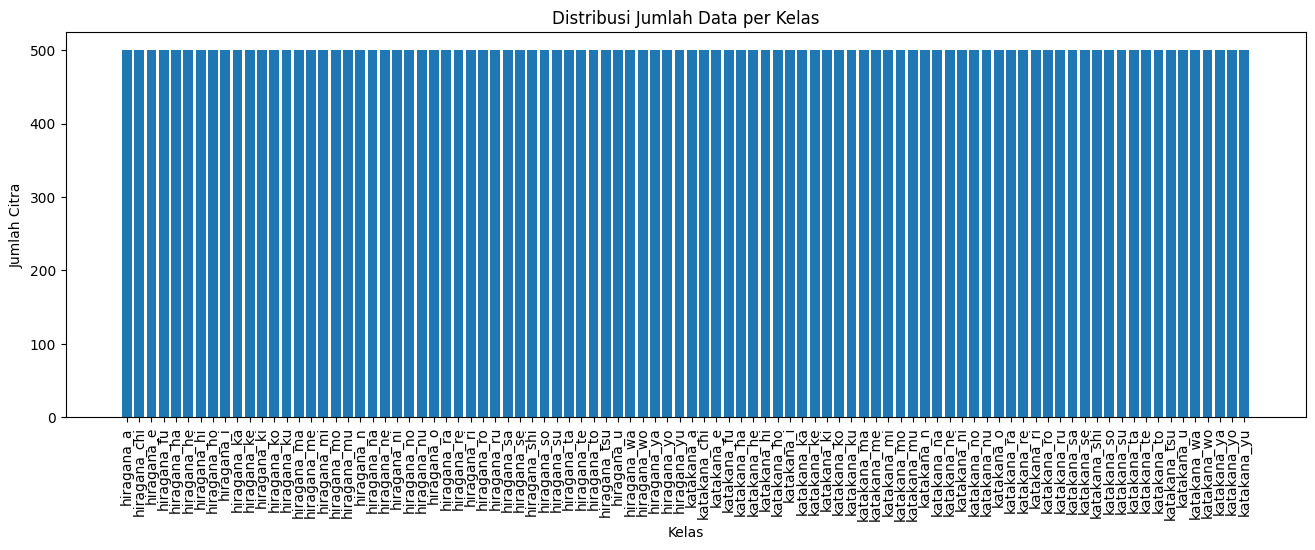

In [7]:
label_counts = Counter(y)

plt.figure(figsize=(16, 5))
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Distribusi Jumlah Data per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")
plt.xticks(rotation=90)
plt.show()

In [8]:
# Normalisasi
X = X.astype("float32") / 255.0

# Tambahkan channel untuk CNN
X = np.expand_dims(X, axis=-1)

# Encode label
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encoding
y_categorical = to_categorical(y_encoded)

print("Shape X:", X.shape)
print("Shape y:", y_categorical.shape)
print("Jumlah kelas:", len(label_encoder.classes_))

Shape X: (46000, 64, 64, 1)
Shape y: (46000, 92)
Jumlah kelas: 92


In [9]:
# Split data menjadi train, validation, test
# 70% train, 15% validation, 15% test

X_train, X_temp, y_train, y_temp, y_train_labels, y_temp_labels = train_test_split(
    X, y_categorical, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_labels
)

print("Shape X_train:", X_train.shape)
print("Shape X_val  :", X_val.shape)
print("Shape X_test :", X_test.shape)

print("Shape y_train:", y_train.shape)
print("Shape y_val  :", y_val.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (36800, 64, 64, 1)
Shape X_val  : (4600, 64, 64, 1)
Shape X_test : (4600, 64, 64, 1)
Shape y_train: (36800, 92)
Shape y_val  : (4600, 92)
Shape y_test : (4600, 92)


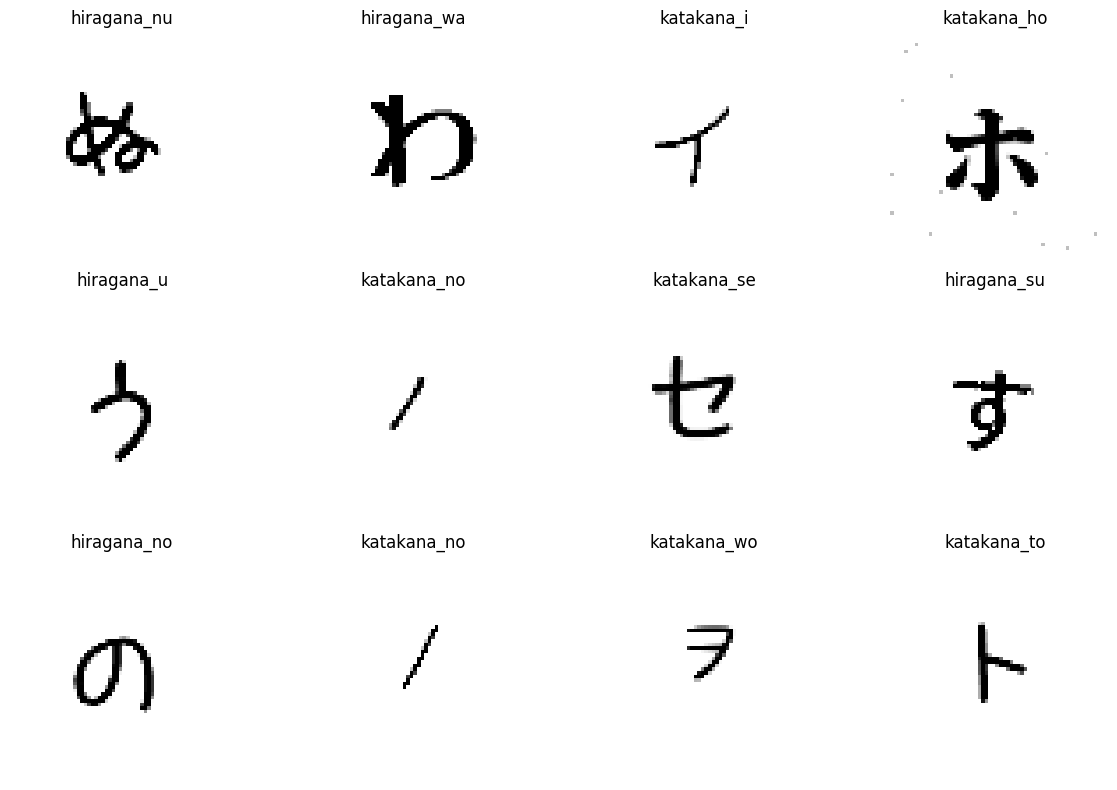

In [10]:
# Visualisasi beberapa data training
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    label_idx = np.argmax(y_train[i])
    plt.title(label_encoder.classes_[label_idx])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [11]:
num_classes = len(label_encoder.classes_)

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 128)         0

In [12]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
1150/1150 [==============================] - 115s 100ms/step - loss: 1.5161 - accuracy: 0.6086 - val_loss: 0.2086 - val_accuracy: 0.9404
Epoch 2/20
1150/1150 [==============================] - 111s 96ms/step - loss: 0.3284 - accuracy: 0.8941 - val_loss: 0.1130 - val_accuracy: 0.9657
Epoch 3/20
1150/1150 [==============================] - 116s 101ms/step - loss: 0.2230 - accuracy: 0.9249 - val_loss: 0.0933 - val_accuracy: 0.9693
Epoch 4/20
1150/1150 [==============================] - 121s 105ms/step - loss: 0.1742 - accuracy: 0.9398 - val_loss: 0.0819 - val_accuracy: 0.9733
Epoch 5/20
1150/1150 [==============================] - 121s 106ms/step - loss: 0.1507 - accuracy: 0.9473 - val_loss: 0.0800 - val_accuracy: 0.9757
Epoch 6/20
1150/1150 [==============================] - 121s 106ms/step - loss: 0.1298 - accuracy: 0.9542 - val_loss: 0.0781 - val_accuracy: 0.9735
Epoch 7/20
1150/1150 [==============================] - 124s 107ms/step - loss: 0.1163 - accuracy: 0.9585 - val_l

In [13]:
# Evaluasi pada data testing
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)

Test Loss     : 0.06827916949987411
Test Accuracy : 0.9752174019813538


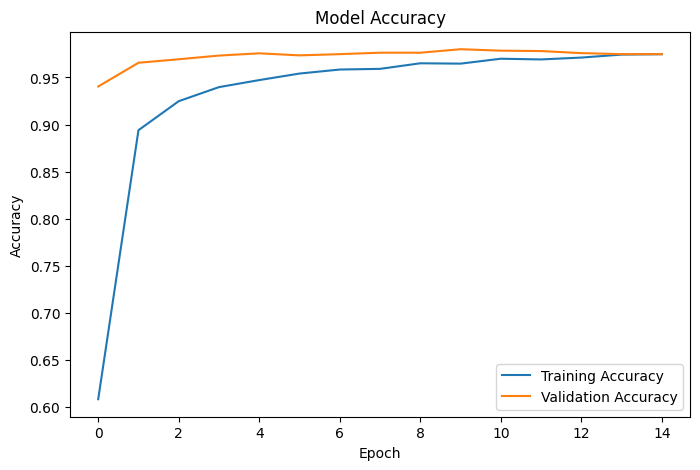

In [14]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

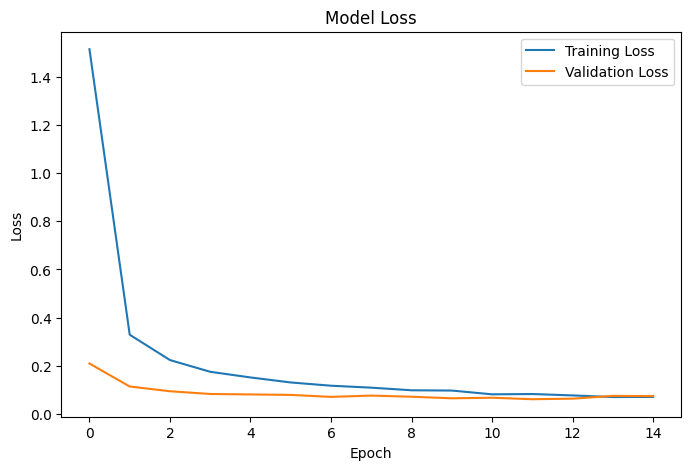

In [15]:
# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
# Simpan model
model.save("japanese_char.h5")
print("Model berhasil disimpan sebagai japanese_char.h5")

Model berhasil disimpan sebagai japanese_char.h5


c:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [17]:
np.save("class_names.npy", label_encoder.classes_)
print("class_names.npy berhasil disimpan")

class_names.npy berhasil disimpan
